In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

deliveries = pd.read_csv('../data/deliveries.csv')

In [3]:
print(deliveries.columns)

Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs',
       'total_runs', 'extras_type', 'is_wicket', 'player_dismissed',
       'dismissal_kind', 'fielder'],
      dtype='object')


In [ ]:
deliveries['is_wicket'] = deliveries['player_dismissed'].apply(lambda x: 1 if pd.notnull(x) else 0)

deliveries['partnership_id'] = deliveries.groupby(['match_id', 'inning'])['is_wicket'].shift(1).fillna(0).cumsum()

partnership_stats = deliveries.groupby(['match_id', 'inning', 'partnership_id']).agg({
    'batting_team': 'first',
    'batter': lambda x: list(x.unique()),
    'non_striker': lambda x: list(x.unique()),
    'batsman_runs': 'sum',   
    'extra_runs': 'sum'     
}).reset_index()

partnership_stats['total_runs'] = partnership_stats['batsman_runs'] + partnership_stats['extra_runs']
partnership_stats['batter_count'] = partnership_stats['batter'].map(len)

partnership_stats = partnership_stats[partnership_stats['total_runs'] >= 0]

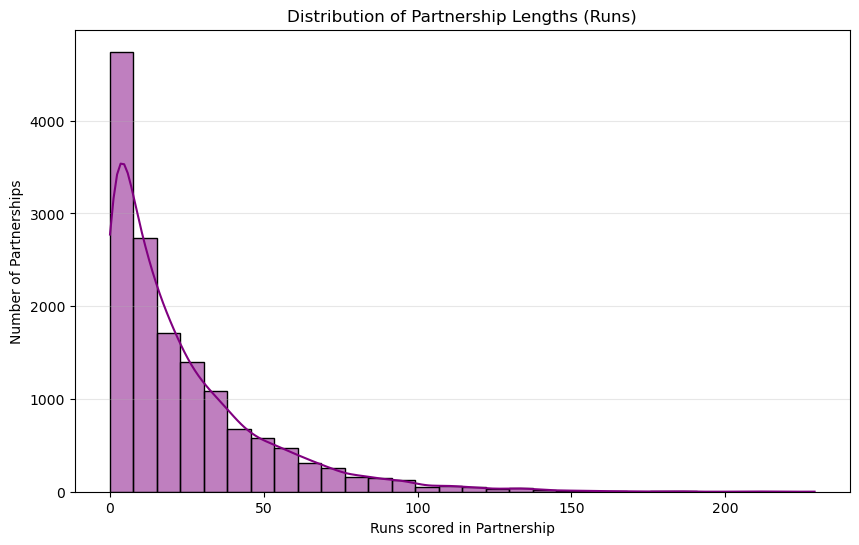

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.histplot(partnership_stats['total_runs'], bins=30, kde=True, color='purple')

plt.title('Distribution of Partnership Lengths (Runs)')
plt.xlabel('Runs scored in Partnership')
plt.ylabel('Number of Partnerships')
plt.grid(axis='y', alpha=0.3)
plt.show()